# Введение

## Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

## Постановка задачи

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

# Описание датасета

Для работы выбран датасет [Dry Bean](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset). 

Датасет описывает морфологические признаки семян сухой фасоли 7 сортов, полученные на основе изображений. Вешне сорта фасоли очень похожи и при ручной сортировке возможны ошибки, поэтому целью работы будет выявление группы таких признаков для автоматизации опредления сорта.

С помощью системы компьютерного зрения были получены фотографии 13 611 зёрен фасоли (7 сортов). Из изображений после этапов сегментации и выделения контуров извлечены 16 признаков, описывающих форму и геометрию зерна:
| Признак             | Роль    | Тип переменной | Описание (рус.)                                                                                    |
| ------------------- | ------- | ---------------| -------------------------------------------------------------------------------------------------- |
| **Area**            | признак | целочисленный  | Площадь зерна (количество пикселей внутри контура боба)                                            |
| **Perimeter**       | признак | вещественный   | Периметр зерна — длина границы контура                                                             |
| **MajorAxisLength** | признак | вещественный   | Длина главной оси эллипса, аппроксимирующего зерно (самая длинная линия через зерно)               |
| **MinorAxisLength** | признак | вещественный   | Длина малой оси эллипса (максимальная линия, перпендикулярная главной оси)                         |
| **AspectRatio**     | признак | вещественный   | Отношение MajorAxisLength к MinorAxisLength (вытянутость формы)                                    |
| **Eccentricity**    | признак | вещественный   | Эксцентриситет эллипса с такими же моментами, как у области зерна                                  |
| **ConvexArea**      | признак | целочисленный  | Площадь выпуклой оболочки: число пикселей в минимальном выпуклом многоугольнике, покрывающем зерно |
| **EquivDiameter**   | признак | вещественный   | Эквивалентный диаметр — диаметр круга с той же площадью, что и зерно                               |
| **Extent**          | признак | вещественный   | Доля площади зерна в его ограничивающем прямоугольнике (bounding box)                              |
| **Solidity**        | признак | вещественный   | Плотность/выпуклость: отношение Area к ConvexArea                                                  |
| **Roundness**       | признак | вещественный   | Округлость, вычисляется как ( \frac{4\pi A}{P^2} )                                                 |
| **Compactness**     | признак | вещественный   | Компактность (мера близости формы к кругу)                                                         |
| **ShapeFactor1**    | признак | вещественный   | Фактор формы 1                                                                                     |
| **ShapeFactor2**    | признак | вещественный   | Фактор формы 2                                                                                     |
| **ShapeFactor3**    | признак | вещественный   | Фактор формы 3                                                                                     |
| **ShapeFactor4**    | признак | вещественный   | Фактор формы 4                                                                                     |
| **Class**           | целевая | категориальный | Сорт фасоли: Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira                                  |

In [64]:
import pandas as pd

df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Из датасета мы сразу уберем метку класса - признак Class. Но в конце будем его использовать для анализа полученных результатов.

In [65]:
y = df["Class"]
df = df.drop(columns=["Class"])
n = df.shape[0]

missing_per_col = df.isna().sum()
print("\nВсего пропусков в датасете:", missing_per_col.sum())
print("\nКоличество записей в датасете:", missing_per_col.sum())



Всего пропусков в датасете: 0

Количество записей в датасете: 0


Как мы видим в датасете отсутвуют пропуски.

# Дескриптивный анализ

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Area,53048.28,44652.00,28122.00,20420.00,254616.00,29324.10,8.599026e+08,2.95,10.80,p=0.000e+00 → Далеко от нормального
1,Perimeter,855.28,794.94,683.34,524.74,1985.37,214.29,4.592007e+04,1.63,3.59,p=3.633e-166 → Далеко от нормального
2,MajorAxisLength,320.14,296.88,277.37,183.60,738.86,85.69,7.343490e+03,1.36,2.53,p=1.661e-136 → Далеко от нормального
3,MinorAxisLength,202.27,192.43,154.31,122.51,460.20,44.97,2.022310e+03,2.24,6.65,p=3.647e-287 → Далеко от нормального
4,AspectRation,1.58,1.55,1.70,1.02,2.43,0.25,6.000000e-02,0.58,0.11,p=1.075e-66 → Далеко от нормального
5,Eccentricity,0.75,0.76,0.81,0.22,0.91,0.09,1.000000e-02,-1.06,1.39,p=5.551e-136 → Далеко от нормального
6,ConvexArea,53768.20,45178.00,37023.00,20684.00,263261.00,29774.92,8.865456e+08,2.94,10.74,p=0.000e+00 → Далеко от нормального
7,EquivDiameter,253.06,238.44,189.22,161.24,569.37,59.18,3.501930e+03,1.95,5.19,p=2.368e-182 → Далеко от нормального
8,Extent,0.75,0.76,0.59,0.56,0.87,0.05,0.000000e+00,-0.90,0.64,p=6.026e-81 → Далеко от нормального
9,Solidity,0.99,0.99,0.96,0.92,0.99,0.00,0.000000e+00,-2.55,12.80,p=5.604e-227 → Далеко от нормального


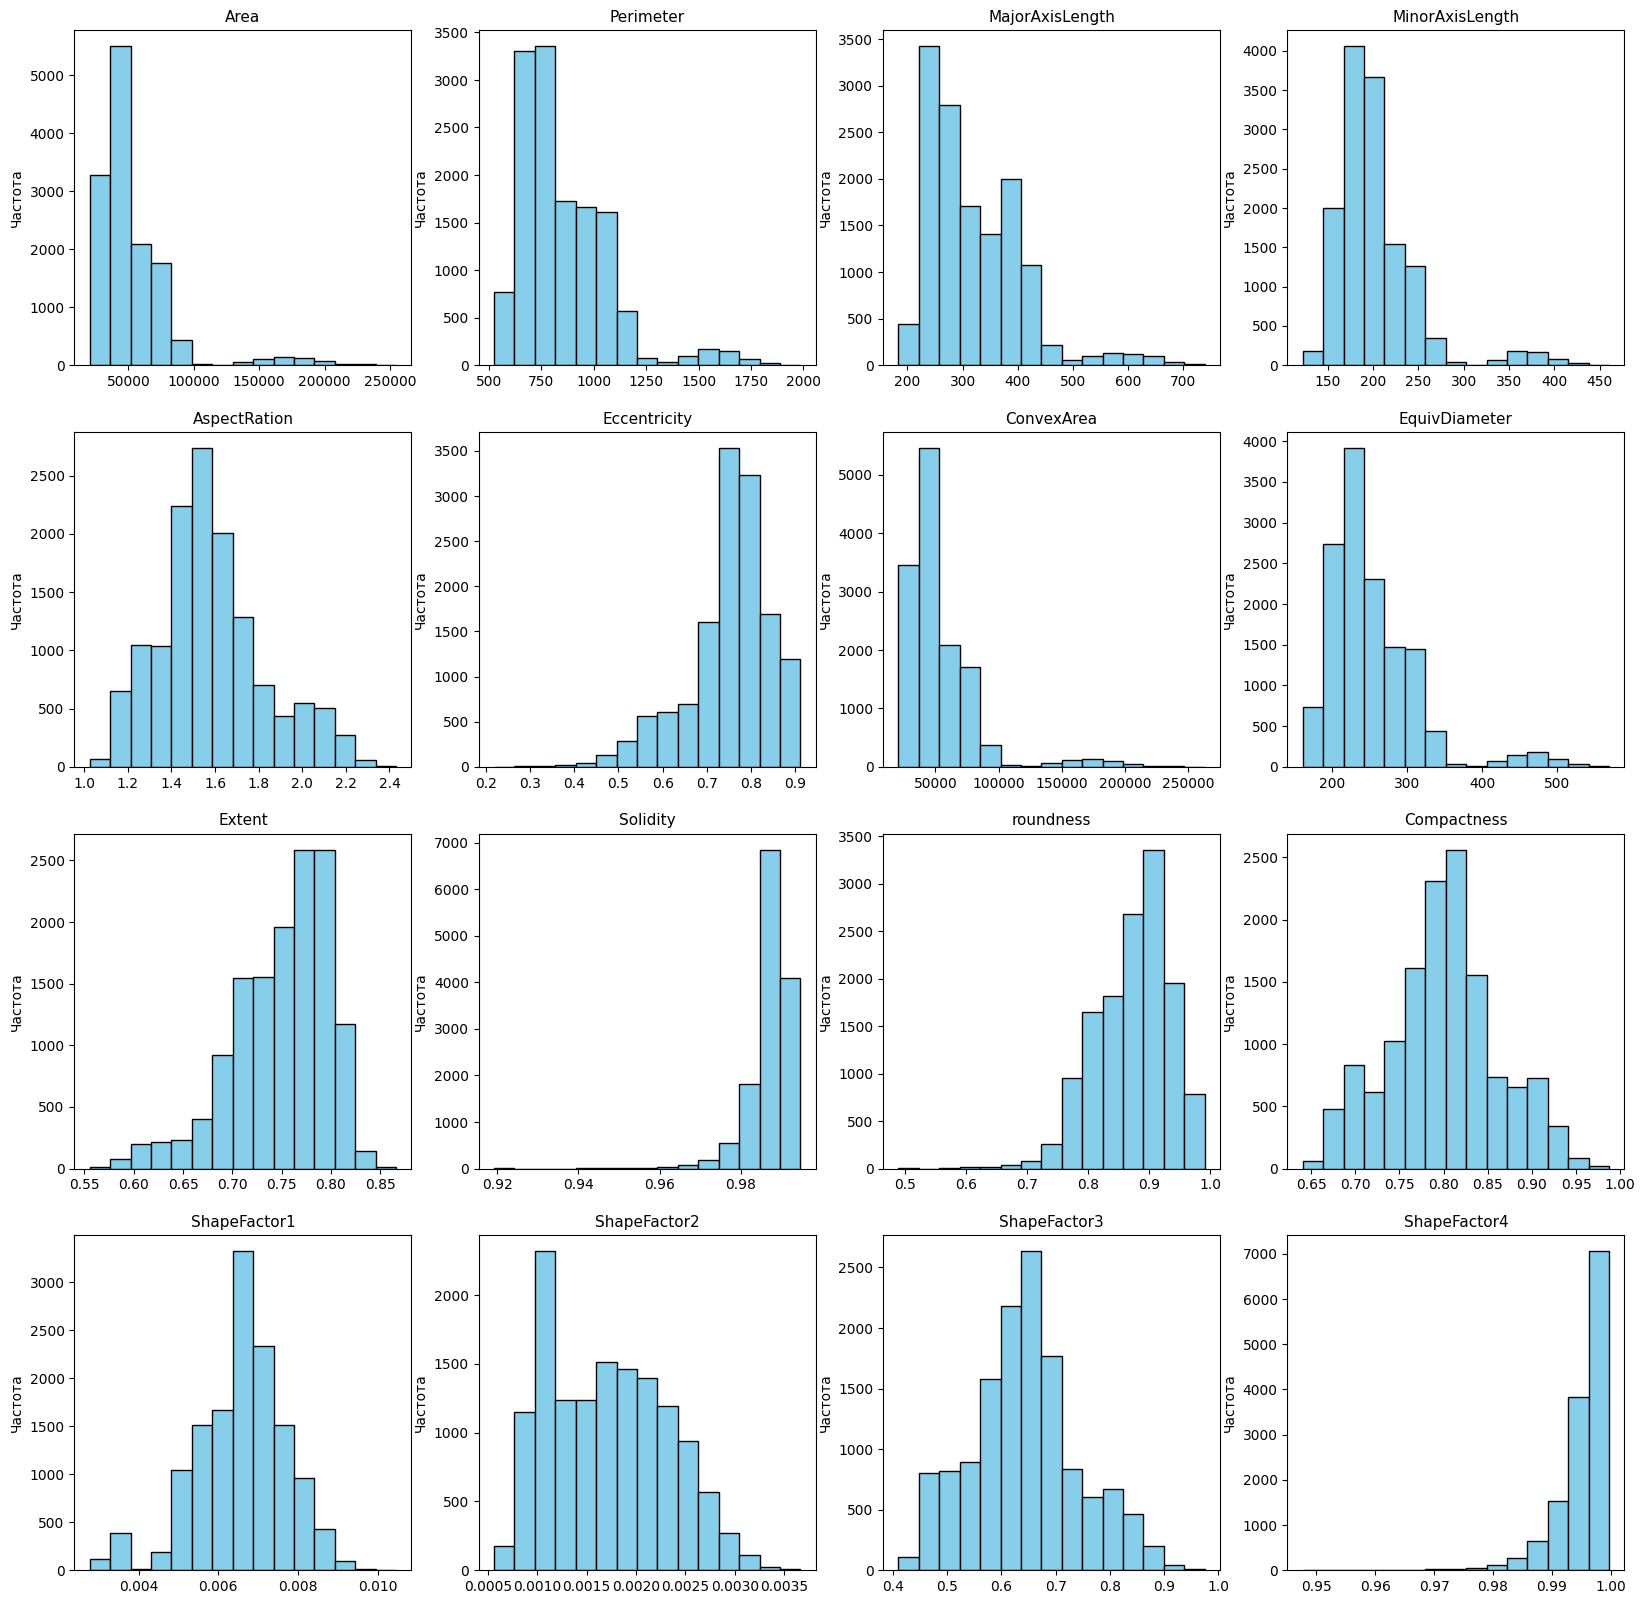

In [72]:

k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
features = df.columns
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    stat["Признак"].append(feature)
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

# TODO: Анализ добавь

# Матрица корреляции

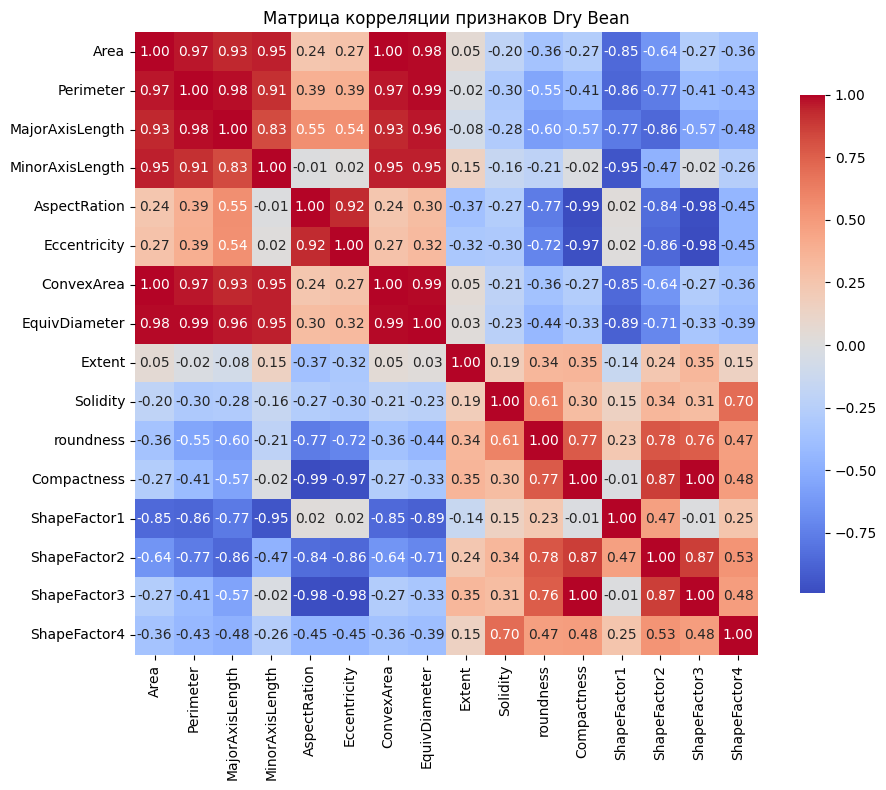

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # <-- числа на карте
    fmt=".2f",         # формат чисел
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков Dry Bean")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
